   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


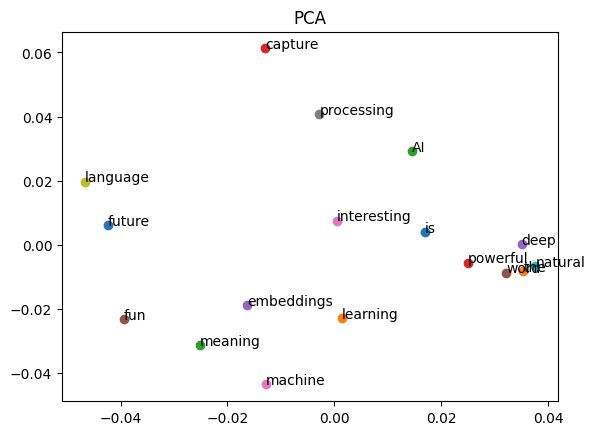

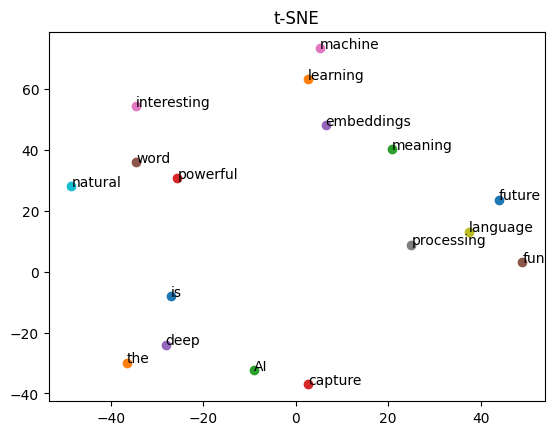

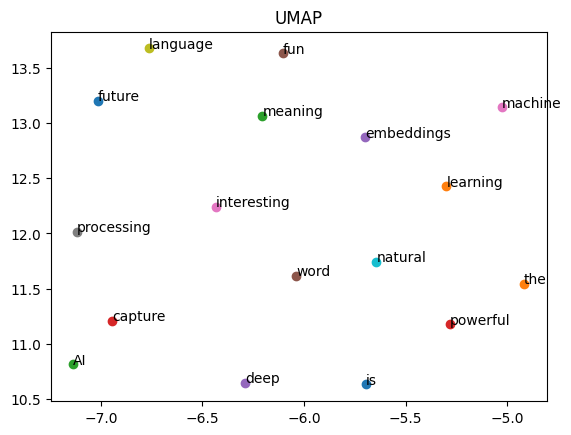

In [1]:
!pip install gensim umap-learn

import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

sentences = [
    "machine learning is fun",
    "deep learning is powerful",
    "AI is the future",
    "natural language processing is interesting",
    "word embeddings capture meaning"
]

data = [sentence.split() for sentence in sentences]

model = Word2Vec(sentences=data, vector_size=50, window=3, min_count=1, workers=2)

words = list(model.wv.index_to_key)
vectors = np.array([model.wv[word] for word in words])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)

tsne = TSNE(n_components=2, random_state=42, perplexity=3)
tsne_result = tsne.fit_transform(vectors)

umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(vectors)

def plot_embeddings(result, title):
    plt.figure()
    for i, word in enumerate(words):
        x, y = result[i]
        plt.scatter(x, y)
        plt.text(x, y, word)
    plt.title(title)
    plt.show()

plot_embeddings(pca_result, "PCA")
plot_embeddings(tsne_result, "t-SNE")
plot_embeddings(umap_result, "UMAP")